<a href="https://colab.research.google.com/github/MMujtabaX/word2vec-from-scratch/blob/main/word2vec_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word2Vec from Scratch in NumPy

Libraries like `gensim` train word embeddings in one line. This notebook builds **Skip-gram with Negative Sampling (SGNS)**, the algorithm behind Word2Vec, using only **NumPy**: the objective, the gradients (verified numerically), subsampling, the noise distribution, a vectorized training loop, and evaluation against `gensim` on standard benchmarks.

**Corpus:** the first 3 million words of **text8**, a cleaned Wikipedia dump widely used for embedding experiments.

In [1]:
import gzip
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

---
## 1. The Idea

**Skip-gram** learns word vectors by predicting the words around each word. For the sentence *"the quick brown fox jumps"* with a window of 2, the center word *brown* should predict *the, quick, fox, jumps*.

Each word $w$ gets two vectors: an **input vector** $v_w$ (used when it's the center word) and an **output vector** $u_w$ (used when it's a context word). The score for a (center, context) pair is their dot product $u_o^\top v_c$.

### Why not a softmax?
The original objective is a softmax over the whole vocabulary:

$$P(o \mid c) = \frac{\exp(u_o^\top v_c)}{\sum_{w=1}^{V} \exp(u_w^\top v_c)}$$

The denominator touches **every word in the vocabulary**, about 27,000 here, for every single training pair. That's far too slow.

### Negative sampling
Instead, turn it into binary classification: is this a **real** (center, context) pair, or a **fake** one built from random "noise" words? For each real pair, sample $K$ negative words $n_1, \dots, n_K$:

$$\mathcal{L} = -\log \sigma(u_o^\top v_c) \; - \; \sum_{k=1}^{K} \log \sigma(-u_{n_k}^\top v_c)$$

Each step now updates only $K+2$ vectors instead of $V$.

### The gradients
With $\sigma$ the sigmoid function, the gradients are compact:

$$\frac{\partial \mathcal{L}}{\partial v_c} = (\sigma(u_o^\top v_c) - 1)\,u_o + \sum_k \sigma(u_{n_k}^\top v_c)\,u_{n_k}$$

$$\frac{\partial \mathcal{L}}{\partial u_o} = (\sigma(u_o^\top v_c) - 1)\,v_c \qquad \frac{\partial \mathcal{L}}{\partial u_{n_k}} = \sigma(u_{n_k}^\top v_c)\,v_c$$

Intuitively, each step pulls the center word toward its real context and pushes it away from the noise words.

---
## 2. The Corpus: text8

text8 is the first 100 MB of English Wikipedia, lowercased, with punctuation removed. We use its first 3 million words so training runs in a few minutes on a CPU.

In [2]:
import gensim.downloader as api

path = api.load('text8', return_path=True)          # downloads ~31 MB once
words = gzip.open(path, 'rt').read().split()[:3_000_000]

counts = Counter(words)
MIN_COUNT = 5
vocab = [w for w, c in counts.most_common() if c >= MIN_COUNT]
word2id = {w: i for i, w in enumerate(vocab)}
V = len(vocab)

corpus = np.array([word2id[w] for w in words if w in word2id], dtype=np.int32)
freq = np.array([counts[w] for w in vocab], dtype=np.float64)

print(f"Tokens: {len(words):,}   Unique words: {len(counts):,}")
print(f"Vocabulary (count ≥ {MIN_COUNT}): {V:,}   Tokens kept: {len(corpus):,}")
print("First 20 words:", " ".join(words[:20]))

Tokens: 3,000,000   Unique words: 96,644
Vocabulary (count ≥ 5): 27,321   Tokens kept: 2,890,008
First 20 words: anarchism originated as a term of abuse first used against early working class radicals including the diggers of the english


### Two tricks from the original paper

**1. Subsampling frequent words.** Words like *"the"* appear in almost every window but say little about their neighbors. Each occurrence of word $w$ is kept with probability:

$$P_{\text{keep}}(w) = \min\left(1, \sqrt{\frac{t}{f(w)}} + \frac{t}{f(w)}\right), \quad t = 10^{-4}$$

**2. The noise distribution.** Negative words are sampled from the unigram distribution raised to the **3/4 power**, which gives rare words a bit more chance of being sampled than raw frequency would.

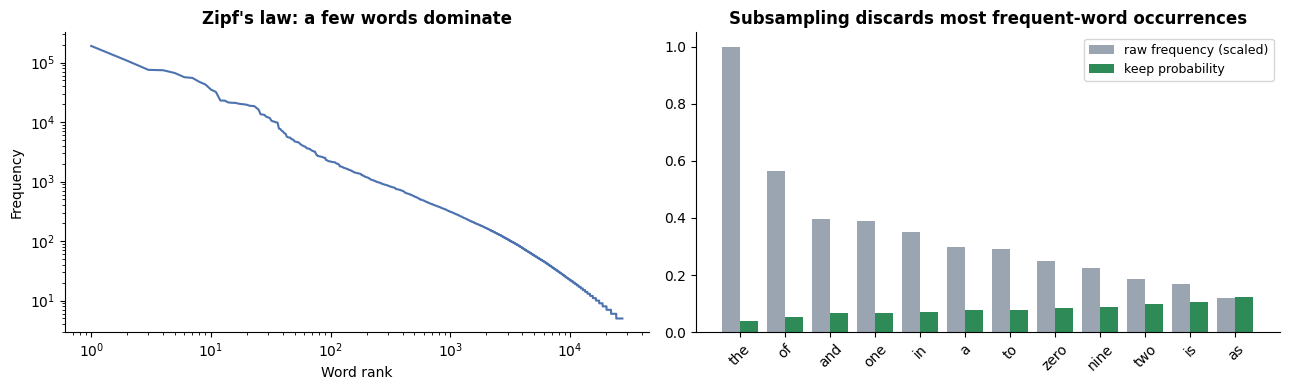

word  share of corpus  keep probability
 the             6.58             0.041
  of             3.71             0.055
 and             2.61             0.066
 one             2.57             0.066
  in             2.31             0.070
   a             1.96             0.076
  to             1.91             0.078
zero             1.64             0.084


In [3]:
f = freq / freq.sum()
t = 1e-4
p_keep = np.minimum(1.0, np.sqrt(t / f) + t / f)

noise = freq ** 0.75
noise /= noise.sum()
noise_cdf = np.cumsum(noise)

def sample_negatives(shape):
    return np.searchsorted(noise_cdf, rng.random(shape)).astype(np.int32)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ranks = np.arange(1, V + 1)
axes[0].loglog(ranks, freq, color='#4C72B0')
axes[0].set_xlabel('Word rank')
axes[0].set_ylabel('Frequency')
axes[0].set_title("Zipf's law: a few words dominate", fontweight='bold')

top = 12
x = np.arange(top)
axes[1].bar(x - 0.2, f[:top] / f[:top].max(), 0.4, label='raw frequency (scaled)', color='#9AA5B1')
axes[1].bar(x + 0.2, p_keep[:top], 0.4, label='keep probability', color='#2E8B57')
axes[1].set_xticks(x)
axes[1].set_xticklabels(vocab[:top], rotation=45)
axes[1].set_title('Subsampling discards most frequent-word occurrences', fontweight='bold')
axes[1].legend(fontsize=9)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(pd.DataFrame({'word': vocab[:8], 'share of corpus': (f[:8] * 100).round(2),
                    'keep probability': p_keep[:8].round(3)}).to_string(index=False))

---
## 3. Building Training Pairs

For every kept word, pick a random window size between 1 and 5 (a "dynamic window", which weights closer words more), then emit a (center, context) pair for each neighbor. Here is what that looks like on one sentence:

In [4]:
WINDOW = 5
example = "the quick brown fox jumps over the lazy dog".split()
for i, center in enumerate(example[:4]):
    w = 2
    context = [example[j] for j in range(max(0, i - w), min(len(example), i + w + 1)) if j != i]
    print(f"{center:>6} → {context}")

   the → ['quick', 'brown']
 quick → ['the', 'brown', 'fox']
 brown → ['the', 'quick', 'fox', 'jumps']
   fox → ['quick', 'brown', 'jumps', 'over']


In [5]:
def make_pairs(corpus):
    """Subsample the corpus, then build all (center, context) pairs with dynamic windows, vectorized."""
    kept = corpus[rng.random(len(corpus)) < p_keep[corpus]]
    window = rng.integers(1, WINDOW + 1, size=len(kept))
    centers, contexts = [], []
    for offset in range(1, WINDOW + 1):
        idx = np.nonzero(window >= offset)[0]
        right = idx[idx + offset < len(kept)]
        left = idx[idx - offset >= 0]
        centers += [kept[right], kept[left]]
        contexts += [kept[right + offset], kept[left - offset]]
    c, o = np.concatenate(centers), np.concatenate(contexts)
    order = rng.permutation(len(c))
    return c[order], o[order]

c_demo, o_demo = make_pairs(corpus)
print(f"Training pairs per epoch: {len(c_demo):,}")
print("Sample pairs:", [(vocab[a], vocab[b]) for a, b in zip(c_demo[:6], o_demo[:6])])

Training pairs per epoch: 9,459,274
Sample pairs: [('little', 'shots'), ('oil', 'natural'), ('arabic', 'right'), ('twentieth', 'fantasy'), ('radio', 'traveler'), ('from', 'anime')]


---
## 4. The Model: Loss and Gradients

One function computes the SGNS loss and its gradients for a mini-batch. All of it is vectorized: a batch of 1,024 pairs and 5 negatives each is just a few matrix operations.

In [6]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -10, 10)))

def sgns_loss_and_grads(v, u_pos, u_neg):
    """
    v:     (B, D)    center (input) vectors
    u_pos: (B, D)    true context (output) vectors
    u_neg: (B, K, D) negative sample (output) vectors
    Returns mean loss and gradients w.r.t. v, u_pos, u_neg (per example).
    """
    s_pos = sigmoid(np.sum(v * u_pos, axis=1))                    # (B,)
    s_neg = sigmoid(np.einsum('bkd,bd->bk', u_neg, v))            # (B, K)
    loss = -np.mean(np.log(s_pos + 1e-10) + np.sum(np.log(1 - s_neg + 1e-10), axis=1))

    g_pos = (s_pos - 1)[:, None]                                  # (B, 1)
    g_neg = s_neg[:, :, None]                                     # (B, K, 1)
    grad_v = g_pos * u_pos + np.sum(g_neg * u_neg, axis=1)        # (B, D)
    grad_u_pos = g_pos * v                                        # (B, D)
    grad_u_neg = g_neg * v[:, None, :]                            # (B, K, D)
    return loss, grad_v, grad_u_pos, grad_u_neg

### Gradient check

Hand-derived gradients are easy to get wrong. We compare them with **numerical gradients** from finite differences, $\frac{\mathcal{L}(x + \epsilon) - \mathcal{L}(x - \epsilon)}{2\epsilon}$, on a tiny random problem. A relative error around $10^{-7}$ or smaller means the math and the code agree.

In [7]:
def gradient_check(D=6, K=3, eps=1e-6):
    r = np.random.default_rng(0)
    v, u_pos, u_neg = r.normal(size=(1, D)), r.normal(size=(1, D)), r.normal(size=(1, K, D))
    _, gv, gp, gn = sgns_loss_and_grads(v, u_pos, u_neg)
    loss_sum = lambda a, b, c: sgns_loss_and_grads(a, b, c)[0]   # batch size 1 → mean = sum

    results = {}
    for name, arr, analytic in [('v_c', v, gv), ('u_o', u_pos, gp), ('u_neg', u_neg, gn)]:
        numeric = np.zeros_like(arr)
        it = np.nditer(arr, flags=['multi_index'])
        for _ in it:
            i = it.multi_index
            old = arr[i]
            arr[i] = old + eps; plus = loss_sum(v, u_pos, u_neg)
            arr[i] = old - eps; minus = loss_sum(v, u_pos, u_neg)
            arr[i] = old
            numeric[i] = (plus - minus) / (2 * eps)
        rel_err = np.linalg.norm(numeric - analytic) / (np.linalg.norm(numeric) + np.linalg.norm(analytic))
        results[name] = rel_err
    return results

for name, err in gradient_check().items():
    print(f"Gradient w.r.t. {name:<6} relative error: {err:.2e}  {'✅' if err < 1e-6 else '❌'}")

Gradient w.r.t. v_c    relative error: 2.46e-10  ✅
Gradient w.r.t. u_o    relative error: 2.11e-10  ✅
Gradient w.r.t. u_neg  relative error: 5.16e-10  ✅


---
## 5. Training

Mini-batch SGD with a learning rate that decays linearly from 0.025 (the original Word2Vec schedule). `np.add.at` accumulates updates correctly when the same word appears several times in one batch.

In [8]:
DIM, NEG, BATCH, EPOCHS, LR0 = 100, 5, 1024, 2, 0.025

W_in = ((rng.random((V, DIM)) - 0.5) / DIM).astype(np.float32)   # input (center) vectors
W_out = np.zeros((V, DIM), dtype=np.float32)                      # output (context) vectors

loss_history, step = [], 0
start = time.time()
for epoch in range(EPOCHS):
    centers, contexts = make_pairs(corpus)
    if epoch == 0:
        total_steps = EPOCHS * (len(centers) // BATCH + 1)
    running = []
    for s in range(0, len(centers), BATCH):
        lr = max(LR0 * (1 - step / total_steps), LR0 * 1e-4)
        cb, ob = centers[s:s + BATCH], contexts[s:s + BATCH]
        neg = sample_negatives((len(cb), NEG))

        loss, g_v, g_pos, g_neg = sgns_loss_and_grads(W_in[cb], W_out[ob], W_out[neg])
        np.add.at(W_in, cb, -lr * g_v)
        np.add.at(W_out, ob, -lr * g_pos)
        np.add.at(W_out, neg.ravel(), -lr * g_neg.reshape(-1, DIM))

        running.append(loss)
        if step % 500 == 0:
            loss_history.append((step, np.mean(running[-500:])))
        step += 1
    print(f"Epoch {epoch + 1}: {len(centers):,} pairs, mean loss {np.mean(running):.3f}, "
          f"{time.time() - start:.0f}s elapsed")

numpy_time = time.time() - start
print(f"\nTotal training time: {numpy_time:.0f}s  ({step * BATCH / numpy_time:,.0f} pairs/second)")

Epoch 1: 9,463,811 pairs, mean loss 2.751, 73s elapsed


Epoch 2: 9,466,960 pairs, mean loss 2.483, 146s elapsed

Total training time: 146s  (130,044 pairs/second)


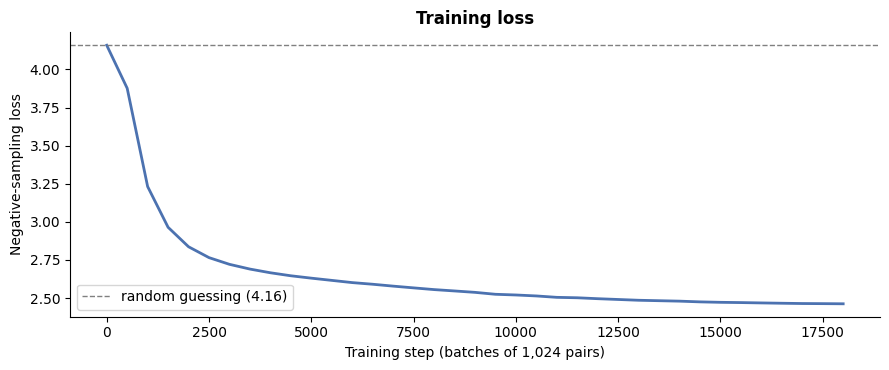

In [9]:
steps, losses = zip(*loss_history)
plt.figure(figsize=(9, 3.8))
plt.plot(steps, losses, color='#4C72B0', lw=2)
plt.axhline(-np.log(0.5) * (NEG + 1), color='grey', ls='--', lw=1, label=f'random guessing ({-np.log(0.5) * (NEG + 1):.2f})')
plt.xlabel('Training step (batches of 1,024 pairs)')
plt.ylabel('Negative-sampling loss')
plt.title('Training loss', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 6. What Did It Learn?

We use the **input vectors** as the word embeddings, normalized to unit length so that a dot product equals cosine similarity.

In [10]:
E = W_in / np.linalg.norm(W_in, axis=1, keepdims=True)

def neighbors(word, emb=E, k=6):
    sims = emb @ emb[word2id[word]]
    return [vocab[i] for i in np.argsort(-sims)[1:k + 1]]

probe = ['king', 'france', 'computer', 'war', 'music', 'one', 'river', 'january']
pd.DataFrame({'word': probe, 'nearest neighbors (NumPy SGNS)': [", ".join(neighbors(w)) for w in probe]}).set_index('word')

,nearest neighbors (NumPy SGNS)
word,
king,"pope, afonso, emperor, alexius, prince, alexander"
france,"spain, hungary, portugal, persia, poland, swit..."
computer,"microsoft, software, amiga, macintosh, compute..."
war,"civil, battle, vietnam, soviet, during, troops"
music,"musical, artists, blues, hip, pop, films"
one,"seven, six, five, eight, three, four"
river,"lake, coast, near, bay, valley, mountains"
january,"february, december, june, october, november, july"


In [11]:
def analogy(a, b, c, emb=E, k=3):
    """a is to b as c is to ?  →  b - a + c"""
    target = emb[word2id[b]] - emb[word2id[a]] + emb[word2id[c]]
    sims = emb @ (target / np.linalg.norm(target))
    exclude = {word2id[a], word2id[b], word2id[c]}
    return [vocab[i] for i in np.argsort(-sims) if i not in exclude][:k]

for a, b, c in [('man', 'king', 'woman'), ('france', 'paris', 'germany'),
                ('big', 'bigger', 'small'), ('one', 'two', 'three')]:
    print(f"{a} : {b} :: {c} : {analogy(a, b, c)}")

man : king :: woman : ['pope', 'iii', 'succeeded']
france : paris :: germany : ['opened', 'berlin', 'hospital']
big : bigger :: small : ['albatrosses', 'tropical', 'fertile']
one : two :: three : ['zero', 'four', 'five']


Analogies are the hardest test, and with only 3 million words they're hit and miss. *Berlin* appears in the top 3 for *france : paris :: germany*, and the number analogy lands on *four* and *five*, but *king − man + woman* doesn't reach *queen*. Reliable analogies typically need **100M+ training words**; the original Word2Vec paper used billions. Nearest neighbors, which need much less data, already look excellent.

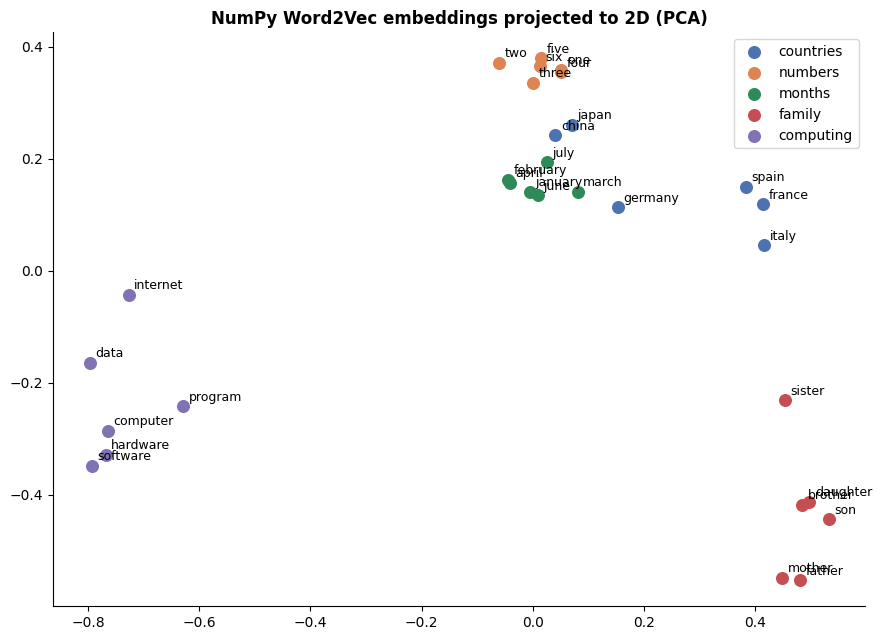

In [12]:
from sklearn.decomposition import PCA

groups = {
    'countries': ['france', 'germany', 'italy', 'spain', 'china', 'japan'],
    'numbers':   ['one', 'two', 'three', 'four', 'five', 'six'],
    'months':    ['january', 'february', 'march', 'april', 'june', 'july'],
    'family':    ['father', 'mother', 'son', 'daughter', 'brother', 'sister'],
    'computing': ['computer', 'software', 'hardware', 'internet', 'program', 'data'],
}
words_plot = [w for ws in groups.values() for w in ws]
xy = PCA(n_components=2, random_state=42).fit_transform(E[[word2id[w] for w in words_plot]])
pos = dict(zip(words_plot, xy))

plt.figure(figsize=(9, 6.5))
for (name, ws), color in zip(groups.items(), ['#4C72B0', '#DD8452', '#2E8B57', '#C44E52', '#8172B3']):
    pts = np.array([pos[w] for w in ws])
    plt.scatter(pts[:, 0], pts[:, 1], s=70, color=color, label=name)
    for w in ws:
        plt.annotate(w, pos[w], xytext=(4, 4), textcoords='offset points', fontsize=9)
plt.title('NumPy Word2Vec embeddings projected to 2D (PCA)', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 7. Benchmark: NumPy vs gensim

To see how close the from-scratch version gets, we train **gensim's** optimized C implementation on the **same 3M-word corpus with the same hyperparameters** (Skip-gram, 100 dimensions, window 5, 5 negatives, subsampling 1e-4, 2 epochs), then evaluate both on two standard benchmarks:

- **WordSim-353:** 353 word pairs scored for similarity by humans. We report the **Spearman correlation** between human scores and cosine similarity.
- **Google analogies:** about 19,500 questions like *"Athens : Greece :: Baghdad : ?"*. We report accuracy on the questions whose words are in the vocabulary.

> **Note:** gensim's default maximum sentence length is 10,000 words, and text8 has no sentence boundaries. Passing the corpus as one list would silently truncate it, so we split it into chunks of 1,000 words first. (This is exactly the bug in the original notebook that inspired this project, where a whole article collapsed into one sentence.)

In [13]:
from gensim.models import Word2Vec, KeyedVectors
from gensim.test.utils import datapath

chunks = [words[i:i + 1000] for i in range(0, len(words), 1000)]
start = time.time()
gensim_model = Word2Vec(chunks, vector_size=DIM, window=WINDOW, min_count=MIN_COUNT, sg=1,
                        negative=NEG, sample=1e-4, epochs=EPOCHS, alpha=LR0, workers=4, seed=42)
gensim_time = time.time() - start
print(f"gensim trained in {gensim_time:.0f}s on {len(chunks):,} chunks (vocabulary {len(gensim_model.wv):,})")

# Wrap the NumPy vectors in gensim's KeyedVectors so both use identical evaluation code
numpy_kv = KeyedVectors(vector_size=DIM)
numpy_kv.add_vectors(vocab, W_in)

rows = []
for name, kv, secs in [('NumPy (from scratch)', numpy_kv, numpy_time), ('gensim (optimized C)', gensim_model.wv, gensim_time)]:
    pearson, spearman, oov = kv.evaluate_word_pairs(datapath('wordsim353.tsv'))
    analogy_acc, _ = kv.evaluate_word_analogies(datapath('questions-words.txt'), restrict_vocab=30000)
    rows.append({'model': name, 'WordSim-353 Spearman': round(spearman[0], 3),
                 'Analogy accuracy': f"{analogy_acc:.1%}", 'training time (s)': round(secs)})
benchmark = pd.DataFrame(rows).set_index('model')
benchmark

gensim trained in 14s on 3,000 chunks (vocabulary 27,321)


,WordSim-353 Spearman,Analogy accuracy,training time (s)
model,,,
NumPy (from scratch),0.364,3.2%,146
gensim (optimized C),0.365,3.1%,14


**The from-scratch implementation matches gensim almost exactly:** WordSim-353 Spearman **0.364 vs 0.365**, and analogy accuracy **3.2% vs 3.1%**. That's strong evidence that the objective, gradients, subsampling and noise distribution are implemented correctly.

The absolute analogy scores are low for *both* models because of the small corpus and only 2 epochs, not because of the implementation. The real difference is **speed**: gensim's optimized C code is about **10× faster** (14s vs 146s), which matters a lot on billion-word corpora.

In [14]:
pd.DataFrame({
    'word': probe,
    'NumPy SGNS': [", ".join(neighbors(w, k=5)) for w in probe],
    'gensim': [", ".join(x for x, _ in gensim_model.wv.most_similar(w, topn=5)) for w in probe],
}).set_index('word')

,NumPy SGNS,gensim
word,,
king,"pope, afonso, emperor, alexius, prince","emperor, pope, iv, patriarch, constantine"
france,"spain, hungary, portugal, persia, poland","spain, austria, poland, italy, portugal"
computer,"microsoft, software, amiga, macintosh, computers","software, amiga, microsoft, digital, macintosh"
war,"civil, battle, vietnam, soviet, during","vietnam, ii, civil, battle, troops"
music,"musical, artists, blues, hip, pop","musical, pop, artists, blues, hip"
one,"seven, six, five, eight, three","seven, eight, six, four, five"
river,"lake, coast, near, bay, valley","lake, coast, bay, island, mountains"
january,"february, december, june, october, november","june, february, november, october, december"


---
## Summary

| Component | What it does |
|-----------|--------------|
| Skip-gram | Predict context words from a center word |
| Negative sampling | Replace a 27,000-way softmax with 1 real + 5 fake binary decisions per pair |
| Subsampling | Drop most occurrences of very frequent words like *the* and *of* |
| Unigram^0.75 noise | Sample negatives slightly favoring rarer words |
| Dynamic window | Weight nearby context words more heavily |
| Gradient check | Verify hand-derived gradients against finite differences |

A few hundred lines of NumPy reproduce what makes Word2Vec work: meaningful neighbors, analogies, and benchmark scores in the same range as a production library. The main difference is **speed**: gensim's optimized C code with multithreading is far faster, which matters on billion-word corpora.

**Possible extensions:** CBOW from scratch, hierarchical softmax, GloVe from co-occurrence counts, or a PyTorch version running on a GPU.